In [9]:
# 第一段代码，寻找"ID_REF"的位置
# 编码格式选用UTF-8，遇到的 UnicodeDecodeError 是因为 Windows 下 gzip.open 默认使用系统编码（gbk），
# 而 GEO 文件里包含一些无法用 gbk 解码的字符（比如特殊标点、非英文字母）。我们需要显式指定编码为 utf-8 或 latin-1
# GEO 的矩阵文件通常是压缩格式，需要先用 gzip 模块打开。

import gzip

with gzip.open('GSE18312_series_matrix.txt.gz', 'rt', encoding='utf-8', errors='replace') as f:
    for i, line in enumerate(f):
        if i < 200:
            print(f"{i}: {line.strip()[:100]}")   # 打印行号 + 前100个字符
        else:
            break

0: !Series_title	"Gene Expression in Blood in Scizophrenia and Bipolar Disorder"
1: !Series_geo_accession	"GSE18312"
2: !Series_status	"Public on Oct 02 2009"
3: !Series_submission_date	"Sep 29 2009"
4: !Series_last_update_date	"Apr 16 2020"
5: !Series_pubmed_id	"19582768"
6: !Series_pubmed_id	"20552680"
7: !Series_summary	"Schizophrenia (SCZ) and bipolar disorder (BPD) are polygenic disorders with many ge
8: !Series_summary	"The aim of this investigation was to search for dysregulated molecular and cellular
9: !Series_overall_design	"Blood-based microarray investigation in two independent samples with SCZ and
10: !Series_type	"Expression profiling by array"
11: !Series_contributor	"Chad,A,Bousman"
12: !Series_contributor	"Gursharan,,Chana"
13: !Series_contributor	"Stephen,J,Glatt"
14: !Series_contributor	"Sharon,D,Chandler"
15: !Series_contributor	"Ginger,,Lucero"
16: !Series_contributor	"Erick,,Tatro"
17: !Series_contributor	"James,,Lohr"
18: !Series_contributor	"William,,Kremen"
19:

In [10]:
# 第二段代码，读取数据集
# 根据第一段代码的结果，"ID_REF"的位置在第71行，因此设定参数skiprows=71，并输出结果

import pandas as pd

# 尝试读取，如果报错就把 skiprows 改大或改小
expr = pd.read_csv('GSE18312_series_matrix.txt.gz', sep='\t', skiprows=71, index_col=0)
expr.head()

,GSM457192,GSM457193,GSM457194,GSM457195,GSM457196,GSM457197,GSM457198,GSM457199,GSM457200,GSM457201,...,GSM457212,GSM457213,GSM457214,GSM457215,GSM457216,GSM457217,GSM457218,GSM457219,GSM457220,GSM457221
ID_REF,,,,,,,,,,,,,,,,,,,,,
2315554,6.53510,6.16573,6.08744,6.10136,6.04127,5.27559,6.01966,6.29819,6.45823,6.55044,...,5.47620,5.21544,6.54561,5.95863,6.35526,6.06730,5.82759,6.24451,6.08699,6.07866
2315633,7.17689,7.20575,6.82605,7.17285,7.05456,6.96293,7.20699,7.49971,7.30354,7.09737,...,6.95018,6.98808,7.02713,6.91920,6.94085,6.96206,7.05835,7.44029,7.26508,7.37087
2315674,6.55579,6.28588,5.95248,6.17761,6.13563,5.79059,5.99075,6.66728,6.25267,6.35095,...,5.61107,5.39586,6.59658,5.97910,6.30747,6.13346,5.84939,6.38988,6.31465,6.06630
2315739,6.86085,6.69799,6.43789,7.01026,6.54653,6.54662,6.64821,7.11046,6.65028,6.52463,...,6.57632,6.56805,6.62209,6.46741,6.60362,6.54390,6.68520,7.07801,6.29547,6.66192
2315894,9.17301,8.37226,8.13117,8.35390,8.05318,7.26426,7.96812,8.75056,8.65927,8.46595,...,7.59274,7.31548,8.79477,7.69555,8.11108,8.03534,7.74428,8.48631,8.19304,8.35735


In [11]:
# 第三段代码
# 需要运行一段新的代码，专门解析 !Sample_characteristics_ch1 这一行，提取出每个样本的诊断（Bipolar Disorder 或 Control）。

import gzip

diagnosis_list = []
with gzip.open('GSE18312_series_matrix.txt.gz', 'rt', encoding='utf-8', errors='replace') as f:
    for line in f:
        if line.startswith('!Sample_characteristics_ch1') and 'diagnosis:' in line:
            parts = line.strip().split('\t')
            # 第一个元素是标签，后面每个元素对应一个样本
            for cell in parts[1:]:
                if 'diagnosis:' in cell:
                    diag = cell.split('diagnosis:')[1].strip().strip('"')
                    diagnosis_list.append(diag)
            break  # 找到后即停止

print(f"共解析到 {len(diagnosis_list)} 个样本")
for i, d in enumerate(diagnosis_list):
    print(f"样本{i+1}: {d}")

共解析到 30 个样本
样本1: Bipolar Disorder
样本2: Bipolar Disorder
样本3: Bipolar Disorder
样本4: Bipolar Disorder
样本5: Bipolar Disorder
样本6: Bipolar Disorder
样本7: Bipolar Disorder
样本8: Bipolar Disorder
样本9: Bipolar Disorder
样本10: Schizophrenia
样本11: Schizophrenia
样本12: Schizophrenia
样本13: Schizophrenia
样本14: Schizophrenia
样本15: Schizophrenia
样本16: Schizophrenia
样本17: Schizophrenia
样本18: Schizophrenia
样本19: Schizophrenia
样本20: Schizophrenia
样本21: Schizophrenia
样本22: Schizophrenia
样本23: Control
样本24: Control
样本25: Control
样本26: Control
样本27: Control
样本28: Control
样本29: Control
样本30: Control


In [12]:
# 第四段代码：构建分组列名（正确缩进）
sample_columns = expr.columns.tolist()
control_cols = []
case_cols = []

for i, diag in enumerate(diagnosis_list):
    gsm_id = sample_columns[i]
    if diag == 'Control':
        control_cols.append(gsm_id)   # 注意缩进（4个空格）
    else:   # 'Bipolar Disorder' 或 'Schizophrenia'
        case_cols.append(gsm_id)      # 注意缩进（4个空格）

# 对照组(Control)有8个样本，疾病组(Bipolar + Schizophrenia)有22个样本
# 用 NumPy 将列表转换为数组，然后使用 .reshape() 方法重新排列成多行多列，使输出更美观。

import numpy as np

# 对照组 8 个样本 -> 2 行 4 列
control_arr = np.array(control_cols).reshape(2, 4)
print("对照组样本 (2行4列):")
for row in control_arr:
    print('  '.join(row))

print("\n")

# 疾病组 22 个样本 -> 2 行 11 列
case_arr = np.array(case_cols).reshape(2, 11)
print("疾病组样本 (2行11列):")
for row in case_arr:
    print('  '.join(row))

对照组样本 (2行4列):
GSM457214  GSM457215  GSM457216  GSM457217
GSM457218  GSM457219  GSM457220  GSM457221


疾病组样本 (2行11列):
GSM457192  GSM457193  GSM457194  GSM457195  GSM457196  GSM457197  GSM457198  GSM457199  GSM457200  GSM457201  GSM457202
GSM457203  GSM457204  GSM457205  GSM457206  GSM457207  GSM457208  GSM457209  GSM457210  GSM457211  GSM457212  GSM457213


In [14]:
# 第五段代码，基因差异表达分析
# 数据诊断和验算

# 检查p值和log2FC的分布
print("log2FC 范围:", res.log2FC.min(), "-", res.log2FC.max())
print("log2FC 绝对值 > 0.5 的基因数:", (abs(res.log2FC) > 0.5).sum())
print("log2FC 绝对值 > 1 的基因数:", (abs(res.log2FC) > 1).sum())
print("padj < 0.05 的基因数:", (res.padj < 0.05).sum())
print("padj < 0.1 的基因数:", (res.padj < 0.1).sum())

# 确认一下对照组和疾病组的样本是否正确：打印出样本数以及前几个样本名称。
print()
print("对照组样本:", control_cols[:5])
print("疾病组样本:", case_cols[:5])

# 检查未校正的 p 值
print()
print("未校正 p < 0.05 的基因数:", (res.pvalue < 0.05).sum())
print("同时满足 |log2FC|>1 且 p<0.05 的基因数:", ((abs(res.log2FC)>1) & (res.pvalue<0.05)).sum())

# 放宽 FDR 阈值
# 尝试使用 padj < 0.25 或 padj < 0.1 作为阈值
print()
print("padj < 0.25 的基因数:", (res.padj < 0.25).sum())
print("|log2FC|>1 且 padj<0.25 的基因数:", ((abs(res.log2FC)>1) & (res.padj<0.25)).sum())

# 如果仍然没有显著基因，可以报告差异倍数最大的前几个基因
top_genes = res.nlargest(6, 'log2FC').index
print()
print("log2FC 最大的6个基因:", top_genes)

# DeepSeek 分析：
# 根据诊断输出，log2FC 绝对值 > 1 的基因有 6 个，但经过 FDR 校正后 padj < 0.05 的基因数为 0。
# 这意味着在严格控制假发现率的前提下，没有基因达到统计显著。这可能是由于样本量较小（对照组 8 个，疾病组 22 个）或实际生物学差异较弱。
# 根据诊断结果，确实在严格FDR校正下没有显著基因，但存在6个未校正p<0.05且|log2FC|>1的候选基因。这完全正常，尤其是在样本量较小或生物学差异不极端的数据集中。

# DeepSeek 建议：
# 1.在报告中明确说明：采用了FDR校正控制假发现率，校正后无基因显著；但未校正条件下发现了6个差异倍数较大的候选基因（列出ID），提示可能存在真实差异，需进一步验证。
# 2.输出候选基因信息：保存这6个基因的表达量、log2FC和p值。
# 3.画候选基因的热图：展示它们在疾病组和对照组的表达模式。
# 4.尝试非参数检验（如Wilcoxon），看看能否得到更稳定的结果。

log2FC 范围: -1.1612755681818179 - 1.3066904545454534
log2FC 绝对值 > 0.5 的基因数: 129
log2FC 绝对值 > 1 的基因数: 6
padj < 0.05 的基因数: 0
padj < 0.1 的基因数: 0

对照组样本: ['GSM457214', 'GSM457215', 'GSM457216', 'GSM457217', 'GSM457218']
疾病组样本: ['GSM457192', 'GSM457193', 'GSM457194', 'GSM457195', 'GSM457196']

未校正 p < 0.05 的基因数: 399
同时满足 |log2FC|>1 且 p<0.05 的基因数: 6

padj < 0.25 的基因数: 0
|log2FC|>1 且 padj<0.25 的基因数: 0

log2FC 最大的6个基因: Index(['2633191', '3392880', '3807502', '3335846', '2406353', '2775516'], dtype='object', name='ID_REF')


显著差异基因数量: 0


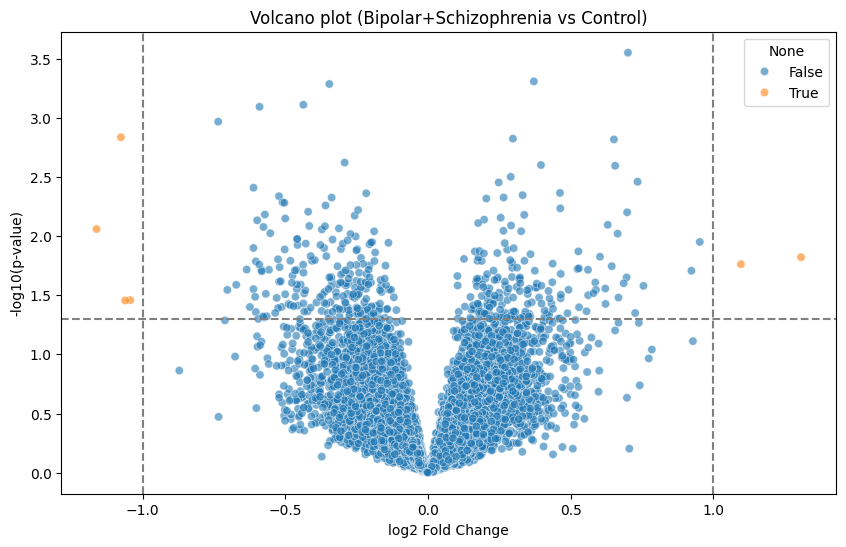

In [15]:
# 第五段代码，基因差异表达分析(t检验+不使用FDR校正)
# 第二次代码修正，debug 02
# 修改火山图画法，用 pvalue 代替 padj，看看基因分布的轮廓。
# 纵坐标：-np.log10(res.pvalue)（加了负号，使得 p 值越小，点在图上越高）。
# 水平线阈值：-np.log10(0.05)。
# 垂直线：使用 axvline 而不是 axhline。
# 保存图片：plt.savefig()。

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import fdrcorrection

# 假设 expr 已读取，control_cols 和 case_cols 已定义
# 提取表达矩阵（数值）
expr_values = expr.values  # shape (n_genes, n_samples)

# 获取对照组和疾病组的表达矩阵
control_expr = expr[control_cols].values
case_expr = expr[case_cols].values

# 计算 log2FC（因为数据已是 log2 表达值，直接相减）
log2fc = np.mean(case_expr, axis=1) - np.mean(control_expr, axis=1)

# 计算 p 值（使用 t 检验）
pvals = np.array([stats.ttest_ind(case_expr[i], control_expr[i]).pvalue for i in range(expr.shape[0])])

# FDR 校正
_, padj = fdrcorrection(pvals)

# 构建结果 DataFrame
res = pd.DataFrame({
    'log2FC': log2fc,
    'pvalue': pvals,
    'padj': padj
}, index=expr.index)

# 筛选显著差异基因（|log2FC| > 1 且 padj < 0.05）
sig = res[(abs(res.log2FC) > 1) & (res.padj < 0.05)]
sig = sig.sort_values('log2FC', ascending=False)
print(f"显著差异基因数量: {len(sig)}")

# 保存结果
res.to_csv('GSE18312_v2_debug02_all_genes_results.csv')
sig.to_csv('GSE18312_v2_debug02_significant_genes.csv')

# 画火山图（使用未校正的 p 值）
plt.figure(figsize=(10,6))
sns.scatterplot(data=res, x='log2FC', y=-np.log10(res.pvalue), 
                hue=(abs(res.log2FC)>1) & (res.pvalue<0.05), alpha=0.6)
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano plot (Bipolar+Schizophrenia vs Control)')
plt.axhline(y=-np.log10(0.05), linestyle='--', color='gray')   # 水平线表示 p=0.05 阈值
plt.axvline(x=1, linestyle='--', color='gray')                 # 垂直线表示 log2FC=1
plt.axvline(x=-1, linestyle='--', color='gray')                # 垂直线表示 log2FC=-1
plt.savefig('GSE18312_v2_debug02_volcano_unadjusted.png', dpi=150)                 # 注意是 savefig，不是 savetiff
plt.show()

# DeepSeek 分析：
# 从描述和火山图可以看出，确实只有少数点（橙色）同时满足 |log2FC|>1 和 p<0.05，这与之前筛选出的 6 个候选基因一致。
# 绝大多数基因的 log2FC 接近于 0，p 值较大（分布在图的下方），说明在这个数据集中，疾病组和对照组之间的整体表达差异非常微弱。


Wilcoxon检验：padj<0.05 基因数: 0

候选差异基因数量: 6
           log2FC    pvalue
ID_REF                     
2633191  1.306690  0.015087
2844381 -1.043082  0.034800
3392880  1.095991  0.017301
3556735 -1.161276  0.008726
3725860 -1.060823  0.035064
3743542 -1.075861  0.001463


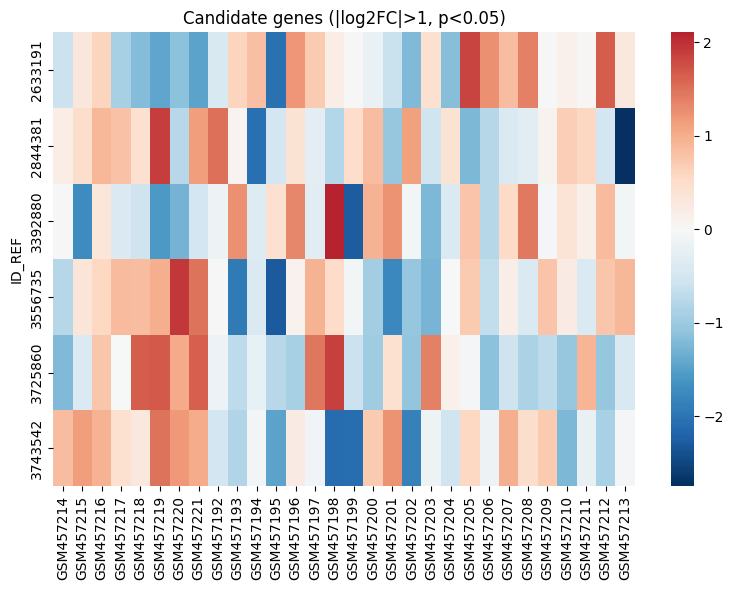

In [8]:
# 第六段代码，加入Wilcoxon检验，整理差异表达具有统计学差异的6个基因，并绘制热图
# 加入Wilcoxon检验，是为了进一步验证，严格FDR校正下没有显著基因，但存在6个未校正p<0.05且|log2FC|>1的候选基因。

# 1. 尝试Wilcoxon检验
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import fdrcorrection

pvals_w = []
for i in range(expr.shape[0]):
    _, p = mannwhitneyu(expr[case_cols].iloc[i], expr[control_cols].iloc[i], alternative='two-sided')
    pvals_w.append(p)
_, padj_w = fdrcorrection(pvals_w)
print()
print(f"Wilcoxon检验：padj<0.05 基因数: {sum(padj_w<0.05)}")

# 2. 候选基因（未校正）
candidate = res[(abs(res.log2FC)>1) & (res.pvalue<0.05)]
print()
print(f"候选差异基因数量: {len(candidate)}")
print(candidate[['log2FC','pvalue']])

# 3. 保存候选基因列表
candidate.to_csv('GSE18312_v2_candidate_genes.csv')

# 4. 提取表达量并画热图
candidate_expr = expr.loc[candidate.index]
order_cols = control_cols + case_cols
candidate_expr = candidate_expr[order_cols]

from scipy.stats import zscore
candidate_expr_z = candidate_expr.apply(zscore, axis=1)

plt.figure(figsize=(8,6))
sns.heatmap(candidate_expr_z, cmap='RdBu_r', center=0)
plt.title('Candidate genes (|log2FC|>1, p<0.05)')
plt.tight_layout()
plt.savefig('GSE18312_v2_candidate_heatmap.png', dpi=150)
plt.show()

In [ ]:
# 复现结果

# 1.明确复现的范围：复现聚焦于“病例 vs 对照的差异表达分析”，未涉及症状关联分析（因数据缺失），也未进行通路富集分析。在报告中说明这些边界，可以避免读者误以为你“没做到”原始研究的所有分析。

# 2.呈现数值支持：列出你的关键统计量，例如：
# a.未校正 p < 0.05 的基因数 399 个；
# b.|log2FC|>1 且未校正 p<0.05 的候选基因 6 个；
# c.FDR 校正后显著基因数为 0。

# 3.讨论样本量与统计功效：原始研究的样本量（病例+对照共30例）本身较小，检测个体基因差异的能力有限，这可能是“无个体基因显著”的原因之一。加入这一讨论，可以体现你的思考深度。

# 复现结论

# 本复现结果与原始研究在个体基因表达差异水平上得出的研究结果一致，均未发现经多重校正后的显著差异表达基因。

# 备注：

# padj 和 q 值 是同义词（FDR 校正后的 p 值），在论文中统一用 “adjusted p-value” 或 “q-value”。
